# Tổng quan dữ liệu và pipeline tiền xử lý

Luồng dữ liệu của hệ thống RAG:

1. Dữ liệu thô: `data/dataset/data.csv`
2. Dữ liệu đã làm giàu trường: `data/dataset/data_enriched.json`
3. Cơ sở tri thức theo nhóm sản phẩm: `data/Thuoc_Metadata/*.json`
4. Chunk dùng cho embedding và Qdrant: `data/chunks/chunks.json`


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

RAW_CSV = ROOT / "data" / "dataset" / "data.csv"
ENRICHED_JSON = ROOT / "data" / "dataset" / "data_enriched.json"
METADATA_DIR = ROOT / "data" / "Thuoc_Metadata"
CHUNKS_JSON = ROOT / "data" / "chunks" / "chunks.json"
IMAGE_DIR = ROOT / "data" / "dataset" / "images"

print("ROOT:", ROOT)
print("Raw CSV:", RAW_CSV.exists(), RAW_CSV.relative_to(ROOT))
print("Enriched JSON:", ENRICHED_JSON.exists(), ENRICHED_JSON.relative_to(ROOT))
print("Metadata dir:", METADATA_DIR.exists(), METADATA_DIR.relative_to(ROOT))
print("Chunks:", CHUNKS_JSON.exists(), CHUNKS_JSON.relative_to(ROOT))

ROOT: /Users/quangnguyentamhuu/Desktop/Chatbox_ChatBox_BanThuocTruSauNongNghiep
Raw CSV: True data/dataset/data.csv
Enriched JSON: True data/dataset/data_enriched.json
Metadata dir: True data/Thuoc_Metadata
Chunks: True data/chunks/chunks.json


## 1. Dữ liệu thô

Dữ liệu ban đầu là file CSV. Mỗi dòng tương ứng với một sản phẩm hoặc một đơn vị tri thức sản phẩm.
Các trường còn chủ yếu ở dạng chuỗi tự nhiên, ví dụ: thành phần, công dụng, triệu chứng, hướng dẫn sử dụng, giá.

In [2]:
raw_df = pd.read_csv(RAW_CSV)
print("Số dòng dữ liệu thô:", len(raw_df))
print("Số cột:", len(raw_df.columns))
display(pd.DataFrame({"column": raw_df.columns}))
display(raw_df.head(5))

Số dòng dữ liệu thô: 500
Số cột: 14


,column
0,product_id
1,ten_san_pham
2,loai
3,thanh_phan
4,quy_cach
5,cong_dung
6,trieu_chung
7,nguyen_nhan
8,doi_tuong_cay_trong
9,thoi_diem_xu_ly


,product_id,ten_san_pham,loai,thanh_phan,quy_cach,cong_dung,trieu_chung,nguyen_nhan,doi_tuong_cay_trong,thoi_diem_xu_ly,huong_dan_su_dung,an_toan_su_dung,gia,url_img
0,sp1,KẼM BORON 50.000ppm,phan_bon,Kẽm Zn: 50.000ppm; Bo B: 50.000ppm; độ ẩm: 1%,Gói 500g,"Tăng khả năng thụ phấn, đậu trái, hạn chế rụng...","Hoa khô, rụng hàng loạt; trái non dễ rụng; lá ...",Thiếu vi lượng Kẽm và Bo trong giai đoạn phân ...,"Cây ăn trái, cà phê, hồ tiêu, lúa, rau màu","Trước ra hoa, sau đậu trái, giai đoạn nuôi trá...","Pha 500g cho phuy 200-250 lít nước, phun đều h...",Không pha chung với thuốc có tính kiềm mạnh; b...,Khoảng 75.000 - 90.000 VNĐ,IMG/sp1
1,sp2,NPK 20-20-15 TE,phan_bon,Đạm N: 20%; Lân P2O5: 20%; Kali K2O: 15%; TE: ...,Bao 25kg,"Cung cấp dinh dưỡng cân đối, giúp cây phát tri...","Cây sinh trưởng chậm, lá nhạt màu, đậu trái kém",Đất thiếu đa lượng NPK hoặc bón phân mất cân đối,"Lúa, bắp, rau màu, cây ăn trái, cây công nghiệp","Giai đoạn sinh trưởng mạnh, sau thu hoạch, trư...",Bón gốc 200-500kg/ha tùy cây trồng và độ phì đất,Không bón sát gốc; tưới nước sau khi bón để tr...,Khoảng 520.000 - 650.000 VNĐ/bao,IMG/sp2
2,sp3,DAP 18-46-0,phan_bon,Đạm N: 18%; Lân hữu hiệu P2O5: 46%,Bao 50kg,"Kích thích ra rễ, phục hồi cây con, tăng sức b...","Rễ yếu, cây còi, chậm bén rễ sau trồng",Thiếu lân trong giai đoạn đầu hoặc đất chua là...,"Lúa, rau màu, cây ăn trái, cà phê, hồ tiêu","Bón lót, bón thúc sớm sau trồng","Bón 100-300kg/ha; cây ăn trái bón 0,2-1kg/gốc ...","Tránh trộn trực tiếp với vôi; bảo quản khô, tr...",Khoảng 1.100.000 - 1.350.000 VNĐ/bao,IMG/sp3
3,sp4,KALI CLORUA KCl 60%,phan_bon,Kali hữu hiệu K2O: 60%; dạng KCl,Bao 50kg,"Tăng độ ngọt, chắc hạt, cứng cây, tăng khả năn...","Trái nhạt, mềm; lá mép vàng cháy; cây yếu dễ đ...","Thiếu Kali hoặc cây đang nuôi trái, nuôi củ cầ...","Lúa, mía, chuối, cây ăn trái, khoai, sắn","Giai đoạn làm đòng, nuôi trái, nuôi củ","Bón 100-250kg/ha; cây ăn trái 0,3-1,5kg/gốc tù...",Không bón quá liều trên cây mẫn cảm Clo; tránh...,Khoảng 750.000 - 950.000 VNĐ/bao,IMG/sp4
4,sp5,CANXI BO MAX,phan_bon,CaO: 15%; Bo B: 2%; MgO: 2%; phụ gia bám dính,Chai 1 lít,"Chống nứt trái, thối đít trái, tăng cứng vỏ và...",Trái cà chua thối đáy; sầu riêng nứt gai; ớt r...,"Thiếu Canxi và Bo, rối loạn vận chuyển dinh dư...","Cà chua, ớt, dưa leo, sầu riêng, xoài, cam quýt","Trước ra hoa, sau đậu trái, giai đoạn trái lớn...",Pha 25-40ml/bình 16 lít; phun 7-10 ngày/lần,Không pha với phân chứa phosphate đậm đặc; lắc...,Khoảng 95.000 - 140.000 VNĐ,IMG/sp5


,column,missing_percent
0,product_id,0.0
1,ten_san_pham,0.0
2,loai,0.0
3,thanh_phan,0.0
4,quy_cach,0.0
5,cong_dung,0.0
6,trieu_chung,0.0
7,nguyen_nhan,0.0
8,doi_tuong_cay_trong,0.0
9,thoi_diem_xu_ly,0.0


,loai,count
0,phan_bon,167
1,thuoc_tru_benh,117
2,thuoc_tru_sau,111
3,thuoc_tru_co,54
4,thuoc_kich_thich_sinh_truong,51


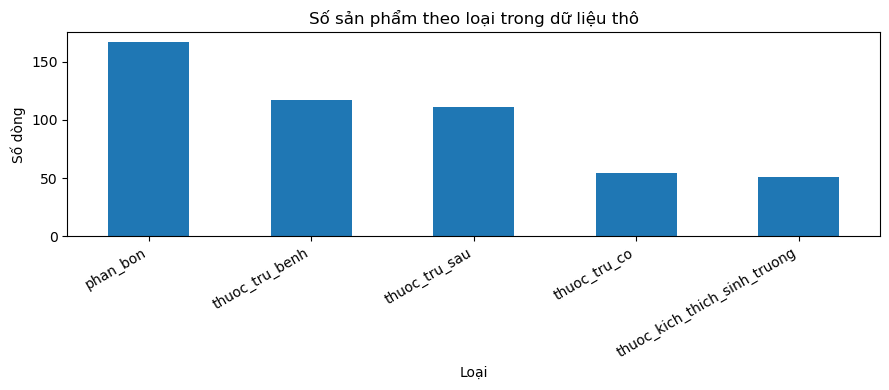

In [3]:
missing_raw = (
    raw_df.isna().mean()
    .mul(100)
    .round(2)
    .rename("missing_percent")
    .reset_index()
    .rename(columns={"index": "column"})
    .sort_values("missing_percent", ascending=False)
)
display(missing_raw)

if "loai" in raw_df.columns:
    type_counts = raw_df["loai"].value_counts().rename_axis("loai").reset_index(name="count")
    display(type_counts)
    ax = type_counts.plot.bar(x="loai", y="count", legend=False, figsize=(9, 4))
    ax.set_title("Số sản phẩm theo loại trong dữ liệu thô")
    ax.set_xlabel("Loại")
    ax.set_ylabel("Số dòng")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

## 2. Tiền xử lý và tăng cường trường

Script `scripts/lam_giau_du_lieu.py` chuyển CSV thô thành JSON giàu cấu trúc.

Các nhóm xử lý chính:

- Chuẩn hóa chuỗi và tách danh sách: công dụng, triệu chứng, cây trồng, thời điểm xử lý, lưu ý an toàn.
- Parse trường phức tạp: `thanh_phan`, `gia`, `huong_dan_su_dung`.
- Sinh trường suy luận bằng rule: `rule_key`, `dac_tinh_benh`, `giai_doan_phu_hop`, `loai_dat_moi_truong`, `goi_y_phoi_hop`, `ly_do_chuyen_gia`.

In [4]:
enriched = json.loads(ENRICHED_JSON.read_text(encoding="utf-8"))
enriched_df = pd.DataFrame(enriched)

print("Số dòng sau làm giàu:", len(enriched_df))
print("Số cột sau làm giàu:", len(enriched_df.columns))

new_columns = [col for col in enriched_df.columns if col not in raw_df.columns]
print("Các trường được thêm/suy luận:")
display(pd.DataFrame({"new_column": new_columns}))

display(enriched_df.head(3))

Số dòng sau làm giàu: 500
Số cột sau làm giàu: 20
Các trường được thêm/suy luận:


,new_column
0,rule_key
1,dac_tinh_benh
2,giai_doan_phu_hop
3,loai_dat_moi_truong
4,goi_y_phoi_hop
5,ly_do_chuyen_gia


,product_id,ten_san_pham,loai,thanh_phan,quy_cach,cong_dung,trieu_chung,nguyen_nhan,doi_tuong_cay_trong,thoi_diem_xu_ly,huong_dan_su_dung,an_toan_su_dung,gia,url_img,rule_key,dac_tinh_benh,giai_doan_phu_hop,loai_dat_moi_truong,goi_y_phoi_hop,ly_do_chuyen_gia
0,sp1,KẼM BORON 50.000ppm,phan_bon,"{'kem_zn': '50.000ppm', 'bo_b': '50.000ppm', '...",Gói 500g,"[Tăng khả năng thụ phấn, đậu trái, hạn chế rụn...","[Hoa khô, rụng hàng loạt, trái non dễ rụng, lá...",[Thiếu vi lượng Kẽm và Bo trong giai đoạn phân...,"[Cây ăn trái, cà phê, hồ tiêu, lúa, rau màu]","[Trước ra hoa, sau đậu trái, giai đoạn nuôi tr...",{'cach_dung': 'Pha 500g cho phuy 200-250 lít n...,"[Không pha chung với thuốc có tính kiềm mạnh, ...","{'tu': 75000, 'den': 90000, 'don_vi': 'VND'}",IMG/sp1,"phan_bon | Hoa khô, rụng hàng loạt; trái non d...",[Bổ sung dinh dưỡng thiếu hụt cho cây],"[Trước ra hoa, Sau đậu trái, Nuôi trái, củ hoặ...","[Đất thiếu vi lượng, Đất canh tác lâu năm, dễ ...","[Chất bám dính sinh học, Phân bón lá Amino Aci...",KẼM BORON 50.000ppm phù hợp vì sản phẩm tập tr...
1,sp2,NPK 20-20-15 TE,phan_bon,"{'dam_n': '20%', 'lan_p2o5': '20%', 'kali_k2o'...",Bao 25kg,"[Cung cấp dinh dưỡng cân đối, giúp cây phát tr...","[Cây sinh trưởng chậm, lá nhạt màu, đậu trái kém]",[Đất thiếu đa lượng NPK hoặc bón phân mất cân ...,"[Lúa, bắp, rau màu, cây ăn trái, cây công nghiệp]","[Giai đoạn sinh trưởng mạnh, sau thu hoạch, tr...",{'cach_dung': 'Bón gốc 200-500kg/ha tùy cây tr...,"[Không bón sát gốc, tưới nước sau khi bón để t...","{'tu': 520000, 'den': 650000, 'don_vi': 'VND/b...",IMG/sp2,"phan_bon | Cây sinh trưởng chậm, lá nhạt màu, ...",[Bổ sung dinh dưỡng thiếu hụt cho cây],"[Cây con, Giai đoạn sinh trưởng mạnh, Trước ra...","[Đất thiếu vi lượng, Đất cần bổ sung Kali cho ...","[Chất bám dính sinh học, Phân bón lá Amino Aci...",NPK 20-20-15 TE phù hợp vì sản phẩm tập trung ...
2,sp3,DAP 18-46-0,phan_bon,"{'dam_n': '18%', 'lan_huu_hieu_p2o5': '46%'}",Bao 50kg,"[Kích thích ra rễ, phục hồi cây con, tăng sức ...","[Rễ yếu, cây còi, chậm bén rễ sau trồng]",[Thiếu lân trong giai đoạn đầu hoặc đất chua l...,"[Lúa, rau màu, cây ăn trái, cà phê, hồ tiêu]","[Bón lót, bón thúc sớm sau trồng]",{'cach_dung': 'Bón 100-300kg/ha; cây ăn trái b...,"[Tránh trộn trực tiếp với vôi, bảo quản khô, t...","{'tu': 1100000, 'den': 1350000, 'don_vi': 'VND...",IMG/sp3,"phan_bon | Rễ yếu, cây còi, chậm bén rễ sau trồng","[Bổ sung dinh dưỡng thiếu hụt cho cây, Giúp câ...","[Cây con, Sau thu hoạch, phục hồi cây]",[Đất phèn hoặc đất chua],"[Chất bám dính sinh học, Phân bón lá Amino Aci...",DAP 18-46-0 phù hợp vì sản phẩm tập trung xử l...


In [5]:
compare_rows = []
sample_index = 0
raw_sample = raw_df.iloc[sample_index].to_dict()
enriched_sample = enriched[sample_index]

interesting_fields = [
    "product_id",
    "ten_san_pham",
    "loai",
    "thanh_phan",
    "cong_dung",
    "trieu_chung",
    "huong_dan_su_dung",
    "gia",
    "rule_key",
    "dac_tinh_benh",
    "giai_doan_phu_hop",
    "loai_dat_moi_truong",
    "goi_y_phoi_hop",
    "ly_do_chuyen_gia",
]

for field in interesting_fields:
    compare_rows.append({
        "field": field,
        "raw_value": raw_sample.get(field, "<chưa có trong CSV thô>"),
        "enriched_value": enriched_sample.get(field, "<không có>"),
    })

pd.set_option("display.max_colwidth", 120)
display(pd.DataFrame(compare_rows))

,field,raw_value,enriched_value
0,product_id,sp1,sp1
1,ten_san_pham,KẼM BORON 50.000ppm,KẼM BORON 50.000ppm
2,loai,phan_bon,phan_bon
3,thanh_phan,Kẽm Zn: 50.000ppm; Bo B: 50.000ppm; độ ẩm: 1%,"{'kem_zn': '50.000ppm', 'bo_b': '50.000ppm', 'do_am': '1%'}"
4,cong_dung,"Tăng khả năng thụ phấn, đậu trái, hạn chế rụng hoa và trái non","[Tăng khả năng thụ phấn, đậu trái, hạn chế rụng hoa và trái non]"
5,trieu_chung,"Hoa khô, rụng hàng loạt; trái non dễ rụng; lá non biến dạng","[Hoa khô, rụng hàng loạt, trái non dễ rụng, lá non biến dạng]"
6,huong_dan_su_dung,"Pha 500g cho phuy 200-250 lít nước, phun đều hai mặt lá","{'cach_dung': 'Pha 500g cho phuy 200-250 lít nước, phun đều hai mặt lá', 'lieu_luong': '500g', 'luong_nuoc': '200-25..."
7,gia,Khoảng 75.000 - 90.000 VNĐ,"{'tu': 75000, 'den': 90000, 'don_vi': 'VND'}"
8,rule_key,<chưa có trong CSV thô>,"phan_bon | Hoa khô, rụng hàng loạt; trái non dễ rụng; lá non biến dạng"
9,dac_tinh_benh,<chưa có trong CSV thô>,[Bổ sung dinh dưỡng thiếu hụt cho cây]


,field,non_empty_percent
0,thanh_phan,100.0
1,cong_dung,100.0
2,trieu_chung,100.0
3,nguyen_nhan,100.0
4,doi_tuong_cay_trong,100.0
5,thoi_diem_xu_ly,100.0
6,huong_dan_su_dung,100.0
7,an_toan_su_dung,100.0
8,gia,100.0
9,dac_tinh_benh,100.0


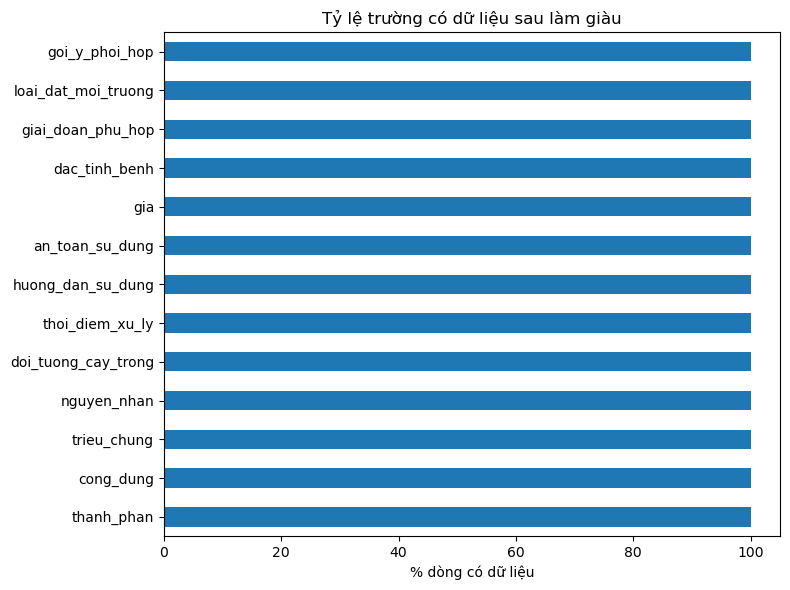

In [6]:
structured_fields = [
    "thanh_phan",
    "cong_dung",
    "trieu_chung",
    "nguyen_nhan",
    "doi_tuong_cay_trong",
    "thoi_diem_xu_ly",
    "huong_dan_su_dung",
    "an_toan_su_dung",
    "gia",
    "dac_tinh_benh",
    "giai_doan_phu_hop",
    "loai_dat_moi_truong",
    "goi_y_phoi_hop",
]

coverage = []
for field in structured_fields:
    non_empty = enriched_df[field].apply(lambda x: bool(x) and x != {}).mean() * 100
    coverage.append({"field": field, "non_empty_percent": round(non_empty, 2)})

coverage_df = pd.DataFrame(coverage).sort_values("non_empty_percent")
display(coverage_df)

ax = coverage_df.plot.barh(x="field", y="non_empty_percent", legend=False, figsize=(8, 6))
ax.set_title("Tỷ lệ trường có dữ liệu sau làm giàu")
ax.set_xlabel("% dòng có dữ liệu")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 3. Xây dựng cơ sở tri thức theo nhóm

Script `scripts/xay_dung_co_so_tri_thuc.py` nhóm dữ liệu đã làm giàu theo `loai`.
Kết quả nằm trong `data/Thuoc_Metadata/`, ví dụ:

- `phan_bon.json`
- `thuoc_tru_benh.json`
- `thuoc_tru_sau.json`
- `thuoc_tru_co.json`
- `thuoc_kich_thich_sinh_truong.json`

{'source': 'data/dataset/data_enriched.json',
 'total_records': 500,
 'groups': {'phan_bon': 167,
  'thuoc_kich_thich_sinh_truong': 51,
  'thuoc_tru_benh': 117,
  'thuoc_tru_co': 54,
  'thuoc_tru_sau': 111}}

,file,records,loai
0,phan_bon.json,167,phan_bon
1,thuoc_kich_thich_sinh_truong.json,51,thuoc_kich_thich_sinh_truong
2,thuoc_tru_benh.json,117,thuoc_tru_benh
3,thuoc_tru_co.json,54,thuoc_tru_co
4,thuoc_tru_sau.json,111,thuoc_tru_sau


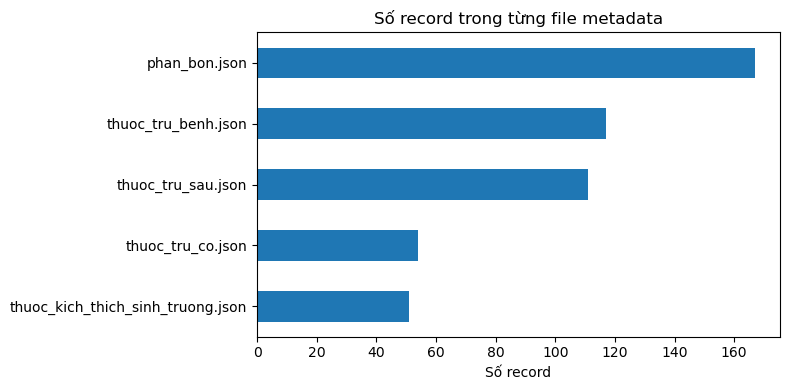

In [7]:
summary_path = METADATA_DIR / "_summary.json"
metadata_summary = json.loads(summary_path.read_text(encoding="utf-8"))
display(metadata_summary)

metadata_rows = []
for path in sorted(METADATA_DIR.glob("*.json")):
    if path.name.startswith("_"):
        continue
    items = json.loads(path.read_text(encoding="utf-8"))
    metadata_rows.append({
        "file": path.name,
        "records": len(items),
        "loai": items[0].get("loai") if items else "",
    })

metadata_df = pd.DataFrame(metadata_rows)
display(metadata_df)

ax = metadata_df.sort_values("records").plot.barh(
    x="file",
    y="records",
    legend=False,
    figsize=(8, 4),
)
ax.set_title("Số record trong từng file metadata")
ax.set_xlabel("Số record")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [8]:
selected_metadata = METADATA_DIR / "thuoc_tru_benh.json"
metadata_items = json.loads(selected_metadata.read_text(encoding="utf-8"))
sample_meta = metadata_items[0]

print("File mẫu:", selected_metadata.relative_to(ROOT))
print("Các key trong record metadata:")
display(pd.DataFrame({"key": list(sample_meta.keys())}))

print("\nRecord mẫu rút gọn:")
display({
    key: sample_meta.get(key)
    for key in [
        "product_id",
        "ten_san_pham",
        "loai",
        "thanh_phan",
        "cong_dung",
        "trieu_chung",
        "huong_dan_su_dung",
        "gia",
        "ly_do_chuyen_gia",
    ]
})

File mẫu: data/Thuoc_Metadata/thuoc_tru_benh.json
Các key trong record metadata:


,key
0,product_id
1,ten_san_pham
2,loai
3,thanh_phan
4,quy_cach
5,cong_dung
6,trieu_chung
7,nguyen_nhan
8,doi_tuong_cay_trong
9,thoi_diem_xu_ly



Record mẫu rút gọn:


{'product_id': 'sp26',
 'ten_san_pham': 'METALAXYL + MANCOZEB 72WP',
 'loai': 'thuoc_tru_benh',
 'thanh_phan': {'metalaxyl': '8%', 'mancozeb': '64%'},
 'cong_dung': ['Phòng trị sương mai', 'thối rễ', 'chết cây con do nấm giả'],
 'trieu_chung': ['Lá có vết vàng loang, mặt dưới có mốc trắng', 'cây con rũ'],
 'huong_dan_su_dung': {'cach_dung': 'Pha 25-35g/bình 16 lít; phun hoặc tưới gốc tùy bệnh',
  'lieu_luong': '35g',
  'luong_nuoc': '16 lít'},
 'gia': {'tu': 35000, 'den': 60000, 'don_vi': 'VND'},
 'ly_do_chuyen_gia': 'METALAXYL + MANCOZEB 72WP phù hợp vì sản phẩm tập trung xử lý nguyên nhân: Nấm Phytophthora, Pythium, Peronospora phát triển khi ẩm cao. Nhờ đó, cây được hỗ trợ phòng trị sương mai, thối rễ, chết cây con do nấm giả, đặc biệt nên dùng ở thời điểm trước và sau mưa, khi bệnh mới chớm.'}

## 4. Chia nhỏ cơ sở tri thức thành chunks

Script `scripts/chia_nho_co_so_tri_thuc.py` chuyển từng record metadata thành văn bản giàu ngữ cảnh,
sau đó chia theo số từ với overlap. Mỗi chunk giữ lại metadata quan trọng:

- `chunk_id`
- `product_id`
- `ten_san_pham`
- `loai`
- `rule_key`
- `source_file`
- `text`

Đây là đầu vào trực tiếp cho embedding và index Qdrant.

In [9]:
chunks = json.loads(CHUNKS_JSON.read_text(encoding="utf-8"))
chunks_df = pd.DataFrame(chunks)
chunks_df["word_count"] = chunks_df["text"].str.split().str.len()

print("Tổng số chunks:", len(chunks_df))
print("Số sản phẩm có chunk:", chunks_df["product_id"].nunique())
display(chunks_df.head(5))

Tổng số chunks: 1000
Số sản phẩm có chunk: 500


,chunk_id,product_id,ten_san_pham,loai,rule_key,chunk_index,source_file,text,word_count
0,sp1::chunk_1,sp1,KẼM BORON 50.000ppm,phan_bon,"phan_bon | Hoa khô, rụng hàng loạt; trái non dễ rụng; lá non biến dạng",1,data/Thuoc_Metadata/phan_bon.json,"Sản phẩm: KẼM BORON 50.000ppm Loại: phan_bon Rule key: phan_bon | Hoa khô, rụng hàng loạt; trái non dễ rụng; lá non ...",220
1,sp1::chunk_2,sp1,KẼM BORON 50.000ppm,phan_bon,"phan_bon | Hoa khô, rụng hàng loạt; trái non dễ rụng; lá non biến dạng",2,data/Thuoc_Metadata/phan_bon.json,"đậu trái; Nuôi trái, củ hoặc hạt; Sau điều kiện thời tiết bất lợi Đất/môi trường phù hợp: Đất thiếu vi lượng; Đất ca...",120
2,sp2::chunk_1,sp2,NPK 20-20-15 TE,phan_bon,"phan_bon | Cây sinh trưởng chậm, lá nhạt màu, đậu trái kém",1,data/Thuoc_Metadata/phan_bon.json,"Sản phẩm: NPK 20-20-15 TE Loại: phan_bon Rule key: phan_bon | Cây sinh trưởng chậm, lá nhạt màu, đậu trái kém Thành ...",220
3,sp2::chunk_2,sp2,NPK 20-20-15 TE,phan_bon,"phan_bon | Cây sinh trưởng chậm, lá nhạt màu, đậu trái kém",2,data/Thuoc_Metadata/phan_bon.json,"đậu trái; Nuôi trái, củ hoặc hạt; Sau thu hoạch, phục hồi cây Đất/môi trường phù hợp: Đất thiếu vi lượng; Đất cần bổ...",131
4,sp3::chunk_1,sp3,DAP 18-46-0,phan_bon,"phan_bon | Rễ yếu, cây còi, chậm bén rễ sau trồng",1,data/Thuoc_Metadata/phan_bon.json,"Sản phẩm: DAP 18-46-0 Loại: phan_bon Rule key: phan_bon | Rễ yếu, cây còi, chậm bén rễ sau trồng Thành phần: dam_n: ...",220


count    1000.00
mean      161.45
std        60.88
min        47.00
25%       102.00
50%       194.50
75%       220.00
max       220.00
Name: word_count, dtype: float64

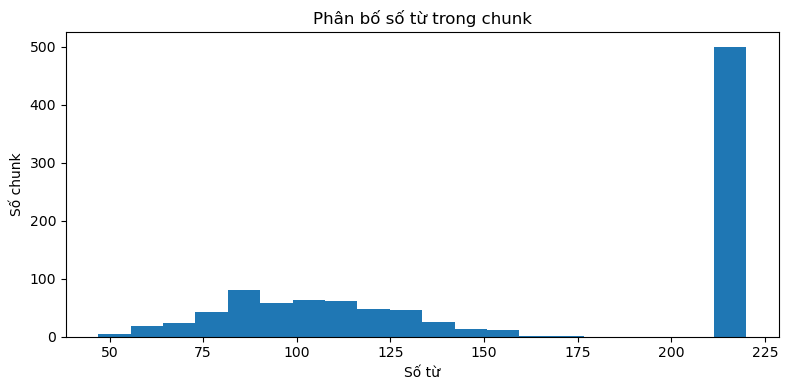

In [10]:
chunk_stats = chunks_df["word_count"].describe().round(2)
display(chunk_stats)

ax = chunks_df["word_count"].plot.hist(bins=20, figsize=(8, 4))
ax.set_title("Phân bố số từ trong chunk")
ax.set_xlabel("Số từ")
ax.set_ylabel("Số chunk")
plt.tight_layout()
plt.show()

In [11]:
chunks_by_type = (
    chunks_df.groupby("loai")
    .agg(
        chunks=("chunk_id", "count"),
        products=("product_id", "nunique"),
        avg_words=("word_count", "mean"),
    )
    .round(2)
    .sort_values("chunks", ascending=False)
)
display(chunks_by_type)

,chunks,products,avg_words
loai,,,
phan_bon,334,167,170.06
thuoc_tru_benh,234,117,161.07
thuoc_tru_sau,222,111,153.36
thuoc_tru_co,108,54,154.12
thuoc_kich_thich_sinh_truong,102,51,159.50


In [12]:
sample_chunk = chunks_df.iloc[0]
print("CHUNK ID:", sample_chunk["chunk_id"])
print("PRODUCT:", sample_chunk["ten_san_pham"])
print("SOURCE:", sample_chunk["source_file"])
print("\nTEXT:")
print(sample_chunk["text"][:2000])

CHUNK ID: sp1::chunk_1
PRODUCT: KẼM BORON 50.000ppm
SOURCE: data/Thuoc_Metadata/phan_bon.json

TEXT:
Sản phẩm: KẼM BORON 50.000ppm Loại: phan_bon Rule key: phan_bon | Hoa khô, rụng hàng loạt; trái non dễ rụng; lá non biến dạng Thành phần: kem_zn: 50.000ppm; bo_b: 50.000ppm; do_am: 1% Quy cách: Gói 500g Công dụng: Tăng khả năng thụ phấn; đậu trái; hạn chế rụng hoa và trái non Triệu chứng: Hoa khô, rụng hàng loạt; trái non dễ rụng; lá non biến dạng Nguyên nhân: Thiếu vi lượng Kẽm và Bo trong giai đoạn phân hóa mầm hoa Cây trồng phù hợp: Cây ăn trái; cà phê; hồ tiêu; lúa; rau màu Thời điểm xử lý: Trước ra hoa; sau đậu trái; giai đoạn nuôi trái non Hướng dẫn sử dụng: cach_dung: Pha 500g cho phuy 200-250 lít nước, phun đều hai mặt lá; lieu_luong: 500g; luong_nuoc: 200-250 lít An toàn sử dụng: Không pha chung với thuốc có tính kiềm mạnh; bảo quản nơi khô ráo Giá tham khảo: tu: 75000; den: 90000; don_vi: VND Đặc tính bệnh/hoạt chất: Bổ sung dinh dưỡng thiếu hụt cho cây Giai đoạn phù hợp: Trướ

## 5. Liên hệ với bước embedding và truy xuất

Sau khi có `data/chunks/chunks.json`, các script embedding sẽ:

- Đọc từng chunk.
- Tạo vector embedding cho trường `text`.
- Lưu vector và payload metadata vào Qdrant.
- Khi người dùng hỏi, hệ thống encode câu hỏi, tìm top-k chunks liên quan, rồi đưa context cho LLM trả lời.

- `scripts/tao_embedding_va_index_qdrant.py`
- `scripts/tao_tat_ca_chi_muc_embedding.py`
- `scripts/benchmark_truy_xuat.py`
- `scripts/benchmark_rag.py`

In [13]:
pipeline = pd.DataFrame([
    {
        "step": 1,
        "input": "data/dataset/data.csv",
        "script": "scripts/lam_giau_du_lieu.py",
        "output": "data/dataset/data_enriched.json",
        "purpose": "Chuẩn hóa, parse trường, suy luận trường mới",
    },
    {
        "step": 2,
        "input": "data/dataset/data_enriched.json",
        "script": "scripts/xay_dung_co_so_tri_thuc.py",
        "output": "data/Thuoc_Metadata/*.json",
        "purpose": "Nhóm metadata theo loại sản phẩm",
    },
    {
        "step": 3,
        "input": "data/Thuoc_Metadata/*.json",
        "script": "scripts/chia_nho_co_so_tri_thuc.py",
        "output": "data/chunks/chunks.json",
        "purpose": "Tạo văn bản tri thức và chia chunk",
    },
    {
        "step": 4,
        "input": "data/chunks/chunks.json",
        "script": "scripts/tao_embedding_va_index_qdrant.py",
        "output": "data/qdrant_db",
        "purpose": "Tạo embedding và lưu vào Qdrant",
    },
])
display(pipeline)

,step,input,script,output,purpose
0,1,data/dataset/data.csv,scripts/lam_giau_du_lieu.py,data/dataset/data_enriched.json,"Chuẩn hóa, parse trường, suy luận trường mới"
1,2,data/dataset/data_enriched.json,scripts/xay_dung_co_so_tri_thuc.py,data/Thuoc_Metadata/*.json,Nhóm metadata theo loại sản phẩm
2,3,data/Thuoc_Metadata/*.json,scripts/chia_nho_co_so_tri_thuc.py,data/chunks/chunks.json,Tạo văn bản tri thức và chia chunk
3,4,data/chunks/chunks.json,scripts/tao_embedding_va_index_qdrant.py,data/qdrant_db,Tạo embedding và lưu vào Qdrant
